# 评估同化算法的性能


In [1]:
%load_ext autoreload
%autoreload 2

## 基本参数设置

In [2]:
# Depending on your combination of package versions, this can raise a lot of TF warnings... 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import xarray as xr
# import torch
# import seaborn as sns
from pathlib import Path
import pickle
import sys 
sys.path.append('../')

In [3]:
!ls /public/home/wangwuxing01/research/fundation/output

da_cycle  forecast  medium_forecast


In [4]:
da_cycle_dir = "/public/home/wangwuxing01/research/fundation/output/da_cycle"
medium_forecast_dir = "/public/home/wangwuxing01/research/fundation/output/medium_forecast"
scaler_dir = "/public/home/wangwuxing01/research/fundation/data/era5_6_hourly/assim_dir_3day/scaler.pkl"
var_idx_dir = "/public/home/wangwuxing01/research/fundation/data/era5_6_hourly/assim_dir_3day/var_idx.npy"

In [5]:
var_idx = [k for k in np.load(var_idx_dir)]

In [6]:
plot_vars = ["Z", "T", "R", "U"]
unit_y = ["(m$^2$ s$^{-2}$)", "(K)", "(%)", "(m s$^{-1}$)"]
plot_idx = [1, 10, 22, 20, 21, 23, 9, 5, 13, 17]

In [7]:
tmp = xr.open_mfdataset("/public/home/wangwuxing01/research/fundation/data/era5_6_hourly/obs_r_2010.nc", 
                  combine="by_coords", parallel=True)

In [8]:
lat, lon = tmp.latitude.values, tmp.longitude.values

In [9]:
idx = 35

In [10]:
xb = np.load(f"{da_cycle_dir}/xb_3day.npy")

xa_dacycle_4dvarnet = np.load(f"{da_cycle_dir}/assim_4dvarnet_obs[8, 9, 10, 11, 20, 21]_xb_3day.npy")[:, 0]
xa_dacycle_vit = np.load(f"{da_cycle_dir}/assim_vit_obs[8, 9, 10, 11, 20, 21]_xb_3day.npy")[:, 0]
xa_dacycle_4dvarformer = np.load(f"{da_cycle_dir}/assim_4dvarformer_obs[8, 9, 10, 11, 20, 21]_xb_3day.npy")[:, 0]

xt = np.load(f"{da_cycle_dir}/real_xb_3day.npy")[:, 0]

In [11]:
z500 = [xb[:,1], xa_dacycle_4dvarnet[:,1], xa_dacycle_vit[:,1], xa_dacycle_4dvarformer[:,1]]
t850 = [xb[:,10], xa_dacycle_4dvarnet[:,10], xa_dacycle_vit[:,10], xa_dacycle_4dvarformer[:,10]]
t2m = [xb[:,22], xa_dacycle_4dvarnet[:,22], xa_dacycle_vit[:,22], xa_dacycle_4dvarformer[:,22]]
u10 = [xb[:,20], xa_dacycle_4dvarnet[:,20], xa_dacycle_vit[:,20], xa_dacycle_4dvarformer[:,20]]
v10 = [xb[:,21], xa_dacycle_4dvarnet[:,21], xa_dacycle_vit[:,21], xa_dacycle_4dvarformer[:,21]]
wsp = [np.sqrt(u10[i]**2+v10[i]**2) for i in range(len(u10))]
wsp_xt = np.sqrt(xt[:,20]**2+xt[:,21]**2)

In [12]:
rmse_z500 = [np.mean(np.sqrt((z500[i]-xt[:,1])**2), axis=0) for i in range(len(z500))]
rmse_t850 = [np.mean(np.sqrt((t850[i]-xt[:,10])**2), axis=0) for i in range(len(t850))]
rmse_t2m = [np.mean(np.sqrt((t2m[i]-xt[:,22])**2), axis=0) for i in range(len(t2m))]
rmse_wspd = [np.mean(np.sqrt((wsp[i]-wsp_xt)**2), axis=0) for i in range(len(wsp))]
rmse = [rmse_z500, rmse_t850, rmse_t2m, rmse_wspd]

In [13]:
titles = ["Background", "4DVarNet", "ViT", "4DVarFormer"]
ylables = ["500hPa geopotential (m$^2$ s$^{-2}$)", "850hPa temperature (K)", "2-m temperature (K)", "10-m wind speed (m s$^{-1}$)"]

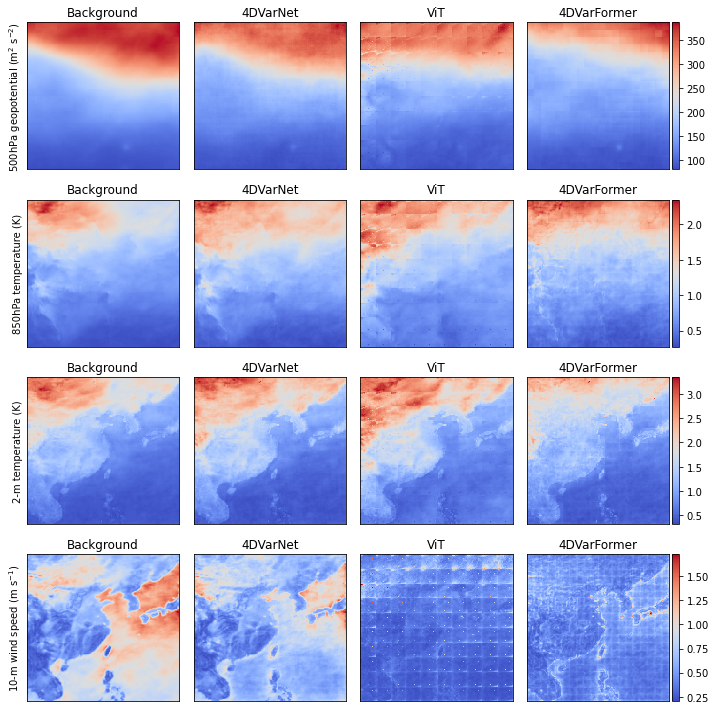

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(4):
    for j in range(4):
        axes[i, j].set_title(titles[j])
        im = axes[i, j].pcolormesh(lon[:-1], lat[:-1], rmse[i][j], cmap="coolwarm")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if j in [0, 4, 8, 12]:
            label = axes[i, j].set_ylabel(ylables[i])
        if j in [3, 7, 11, 15]:
            divider = make_axes_locatable(axes[i, j])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im, cax=cax)
                    
plt.tight_layout()
plt.savefig(f'diff_spatial_all.jpg',dpi=300)
plt.savefig(f'diff_spatial_all.pdf',dpi=300)
plt.show()

In [15]:
titles = ["Background", "4DVarNet", "ViT", "4DVarFormer"]
ylables = ["500hPa relative humidity (%)", "500hPa temperature (K)", "850hPa relative humidity (%)", "850hPa temperature (K)"]

In [16]:
xa_dacycle_4dvarnet_temp = np.load(f"{da_cycle_dir}/assim_4dvarnet_obs[8, 9, 10, 11]_xb_3day.npy")[:, 0]
xa_dacycle_vit_temp = np.load(f"{da_cycle_dir}/assim_vit_obs[8, 9, 10, 11]_xb_3day.npy")[:, 0]
xa_dacycle_4dvarformer_temp = np.load(f"{da_cycle_dir}/assim_4dvarformer_obs[8, 9, 10, 11]_xb_3day.npy")[:, 0]

In [17]:
r500_temp = [xb[:,5], xa_dacycle_4dvarnet_temp[:,5], xa_dacycle_vit_temp[:,5], xa_dacycle_4dvarformer_temp[:,5]]
t500_temp = [xb[:,9], xa_dacycle_4dvarnet_temp[:,9], xa_dacycle_vit_temp[:,9], xa_dacycle_4dvarformer_temp[:,9]]
r850_temp = [xb[:,6], xa_dacycle_4dvarnet_temp[:,6], xa_dacycle_vit_temp[:,6], xa_dacycle_4dvarformer_temp[:,6]]
t850_temp = [xb[:,10], xa_dacycle_4dvarnet_temp[:,10], xa_dacycle_vit_temp[:,10], xa_dacycle_4dvarformer_temp[:,10]]

In [18]:
rmse_r500_temp = [np.mean(np.sqrt((r500_temp[i]-xt[:,5])**2), axis=0) for i in range(len(r500_temp))]
rmse_t500_temp = [np.mean(np.sqrt((t500_temp[i]-xt[:,9])**2), axis=0) for i in range(len(t500_temp))]
rmse_r850_temp = [np.mean(np.sqrt((r850_temp[i]-xt[:,6])**2), axis=0) for i in range(len(r850_temp))]
rmse_t850_temp = [np.mean(np.sqrt((t850_temp[i]-xt[:,10])**2), axis=0) for i in range(len(t850_temp))]
rmse_tmep = [rmse_r500_temp, rmse_t500_temp, rmse_r850_temp, rmse_t850_temp]

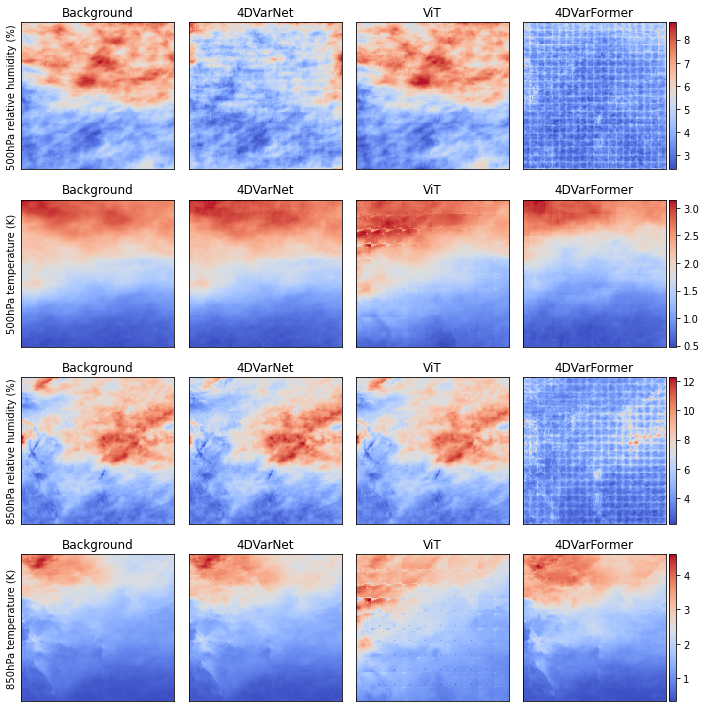

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(4):
    for j in range(4):
        axes[i, j].set_title(titles[j])
        im = axes[i, j].pcolormesh(lon[:-1], lat[:-1], rmse_tmep[i][j], cmap="coolwarm")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if j in [0, 4, 8, 12]:
            label = axes[i, j].set_ylabel(ylables[i])
        if j in [3, 7, 11, 15]:
            divider = make_axes_locatable(axes[i, j])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im, cax=cax)
                    
plt.tight_layout()
plt.savefig(f'diff_spatial_temp.jpg',dpi=300)
plt.savefig(f'diff_spatial_temp.pdf',dpi=300)
plt.show()

In [20]:
titles = ["Background", "4DVarNet", "ViT", "4DVarFormer"]
ylables = ["500hPa geopotential (m$^2$ s$^{-2}$)", "500hPa geopotential (m$^2$ s$^{-2}$)", 
           "mean sea level pressure (Pa)", "10-m wind speed (m s$^{-1}$)"]

In [21]:
xa_dacycle_4dvarnet_wind = np.load(f"{da_cycle_dir}/assim_4dvarnet_obs[20, 21]_xb_3day.npy")[:, 0]
xa_dacycle_vit_wind = np.load(f"{da_cycle_dir}/assim_vit_obs[20, 21]_xb_3day.npy")[:, 0]
xa_dacycle_4dvarformer_wind = np.load(f"{da_cycle_dir}/assim_4dvarformer_obs[20, 21]_xb_3day.npy")[:, 0]

In [22]:
z500_wind = [xb[:,1], xa_dacycle_4dvarnet_wind[:,1], xa_dacycle_vit_wind[:,1], xa_dacycle_4dvarformer_wind[:,1]]
z850_wind = [xb[:,2], xa_dacycle_4dvarnet_wind[:,2], xa_dacycle_vit_wind[:,2], xa_dacycle_4dvarformer_wind[:,2]]
msl_wind = [xb[:,23], xa_dacycle_4dvarnet_wind[:,23], xa_dacycle_vit_wind[:,23], xa_dacycle_4dvarformer_wind[:,23]]
u10_wind = [xb[:,20], xa_dacycle_4dvarnet_wind[:,20], xa_dacycle_vit_wind[:,20], xa_dacycle_4dvarformer_wind[:,20]]
v10_wind = [xb[:,21], xa_dacycle_4dvarnet_wind[:,21], xa_dacycle_vit_wind[:,21], xa_dacycle_4dvarformer_wind[:,21]]
wsp_wind = [np.sqrt(u10_wind[i]**2+v10_wind[i]**2) for i in range(len(u10_wind))]

In [23]:
rmse_z500_wind = [np.mean(np.sqrt((z500_wind[i]-xt[:,1])**2), axis=0) for i in range(len(z500))]
rmse_z850_wind = [np.mean(np.sqrt((z850_wind[i]-xt[:,2])**2), axis=0) for i in range(len(z850_wind))]
rmse_msl_wind = [np.mean(np.sqrt((msl_wind[i]-xt[:,23])**2), axis=0) for i in range(len(msl_wind))]
rmse_wspd_wind = [np.mean(np.sqrt((wsp_wind[i]-wsp_xt)**2), axis=0) for i in range(len(wsp))]
rmse_wind = [rmse_z500_wind, rmse_z850_wind, rmse_msl_wind, rmse_wspd_wind]

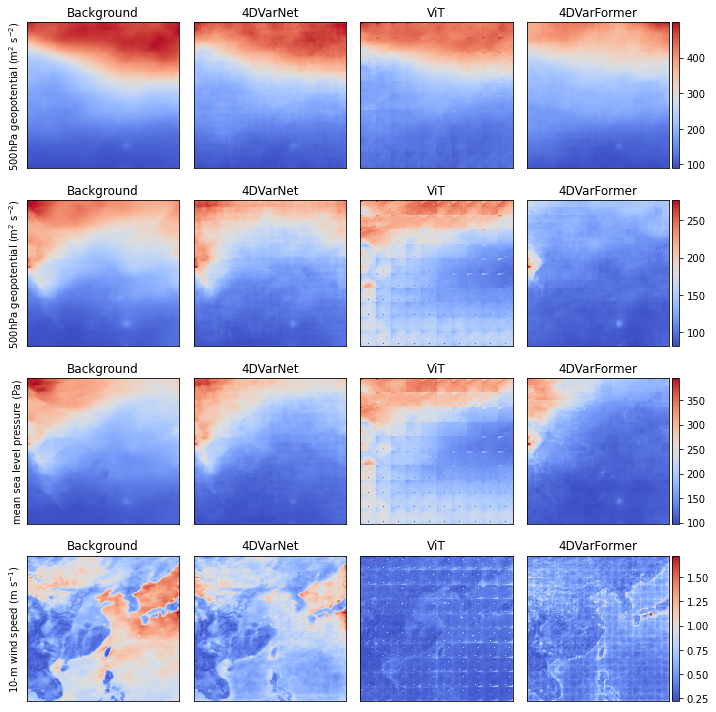

In [24]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(4):
    for j in range(4):
        axes[i, j].set_title(titles[j])
        im = axes[i, j].pcolormesh(lon[:-1], lat[:-1], rmse_wind[i][j], cmap="coolwarm")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if j in [0, 4, 8, 12]:
            label = axes[i, j].set_ylabel(ylables[i])
        if j in [3, 7, 11, 15]:
            divider = make_axes_locatable(axes[i, j])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im, cax=cax)
                    
plt.tight_layout()
plt.savefig(f'diff_spatial_wind.jpg',dpi=300)
plt.savefig(f'diff_spatial_wind.pdf',dpi=300)
plt.show()